# 0. IMPORTAR LIBRERÍAS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.linear_model import LinearRegression
from sklearn.metrics import *
from prophet import Prophet
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from scipy import stats
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
import joblib
import warnings
warnings.filterwarnings('ignore')

c:\Users\ingen\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1 INGESTIÓN O CARGA DE DATOS

In [2]:
# Cargamos el dataset de frutas y vegetales
df = pd.read_csv(r'https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv')
df.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


# 2 INSPECCIÓN INICIAL 

## 2.1 INFORMACIÓN DEL DATASET 

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    object 
 1   sales   366 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.8+ KB


# 3 CRIBADO DE VARIABLES 

## 3.1 VERIFICACIÓN DE VALORES NULOS POR COLUMNAS

In [6]:
print("Valores faltantes por columna:")
print(df.isnull().sum())

Valores faltantes por columna:
date     0
sales    0
dtype: int64


## 3.2 CONVERSIÓN DE COLUMNA DATE A FORMATO DATETIME

In [8]:
df['date'] = pd.to_datetime(df['date']).dt.normalize()
df

,date,sales
0,2022-09-03,55.292157
1,2022-09-04,53.803211
2,2022-09-05,58.141693
3,2022-09-06,64.530899
4,2022-09-07,66.013633
...,...,...
361,2023-08-30,989.600354
362,2023-08-31,994.987326
363,2023-09-01,995.814415
364,2023-09-02,997.350214


## 3.3 TOTAL DE DÍAS REGISTRADOS 

In [11]:
rango_total = (df['date'].max() - df['date'].min()).days + 1  # +1 para incluir ambos extremos
fechas_unicas = df['date'].nunique()
fechas_faltantes = rango_total - fechas_unicas

print(f"Rango total de días: {rango_total}")
print(f"Fechas únicas en el dataset: {fechas_unicas}")
print(f"Fechas faltantes: {fechas_faltantes}")

Rango total de días: 366
Fechas únicas en el dataset: 366
Fechas faltantes: 0


# 4 PREPARACIÓN DE DATOS PARA EL TIEMPO DE ESTUDIO 

In [12]:
# Establecer la fecha como índice y ordenar
df_ts = df.copy()
df_ts.set_index('date', inplace=True)
df_ts = df_ts.sort_index()

print("Serie temporal preparada:")
print(f"Forma: {df_ts.shape}")
print(f"Período: {df_ts.index.min()} a {df_ts.index.max()}")
print(f"\nPrimeras filas:")
df_ts.head()


Serie temporal preparada:
Forma: (366, 1)
Período: 2022-09-03 00:00:00 a 2023-09-03 00:00:00

Primeras filas:


,sales
date,
2022-09-03,55.292157
2022-09-04,53.803211
2022-09-05,58.141693
2022-09-06,64.530899
2022-09-07,66.013633


## 4.1 VISUALIZACIÓN DE PRECIOS/VENTAS RESPECTO AL TIEMPO DE ESTUDIO 

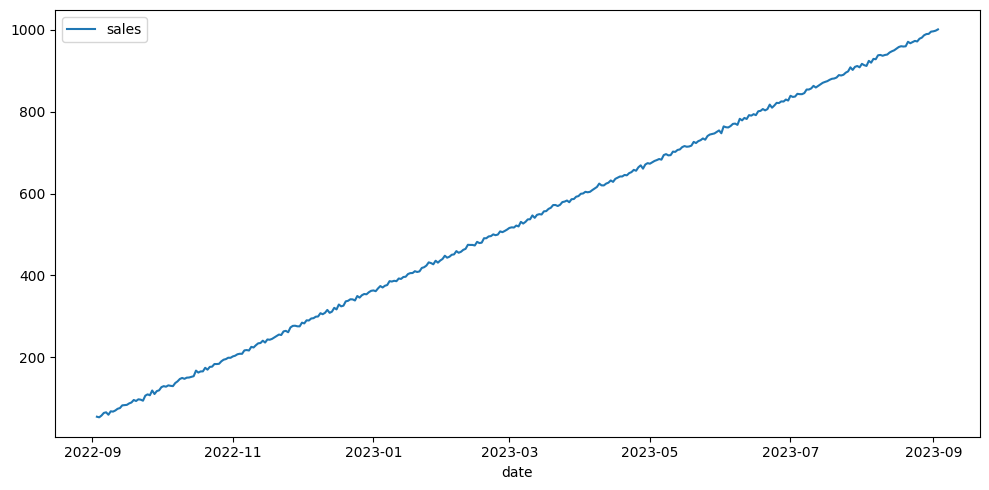

In [13]:
fig, axis = plt.subplots(figsize = (10, 5))
sns.lineplot(data = df_ts, ax=axis)
plt.tight_layout()
plt.show()

# 5. CÁLCULO DEL TENSOR (FRECUENCIA TEMPORAL MÍNIMA DE OBSERVACIONES)

Te dice cada cuánto ocurre la observación, y eso es clave para modelar bien la serie.

In [13]:
# Calcular las diferencias entre fechas consecutivas
diferencias = df_ts.index.to_series().diff()

# Encontrar la diferencia más frecuente (tensor)
tensor_valor = diferencias.mode()[0]

# Frecuencia inferida automáticamente por pandas
frecuencia_inferida = df_ts.index.inferred_freq

# Análisis de distribución de diferencias
print("=" * 60)
print("ANÁLISIS DEL TENSOR (Frecuencia Temporal)")
print("=" * 60)
print(f"\nTensor (diferencia más común): {tensor_valor}")
print(f"Frecuencia inferida por pandas: {frecuencia_inferida}")

# Mostrar todas las diferencias únicas para detectar irregularidades
diferencias_unicas = diferencias.value_counts().sort_index()
print(f"\nDistribución de diferencias temporales:")
print(diferencias_unicas)

# Interpretación
print("\n" + "=" * 60)
print("INTERPRETACIÓN:")
print("=" * 60)
if tensor_valor == pd.Timedelta(days=1):
    print("✓ El tensor es DIARIO (1 día)")
elif tensor_valor == pd.Timedelta(hours=1):
    print("✓ El tensor es HORARIO (1 hora)")
elif tensor_valor == pd.Timedelta(days=7):
    print("✓ El tensor es SEMANAL (7 días)")
elif tensor_valor == pd.Timedelta(days=30) or tensor_valor == pd.Timedelta(days=31):
    print("✓ El tensor es MENSUAL (~30 días)")
else:
    print(f"✓ El tensor es de: {tensor_valor}")
    
# Verificar si la frecuencia es regular o irregular
if len(diferencias_unicas) == 1:
    print("✓ La serie tiene frecuencia REGULAR")
else:
    print("⚠ La serie tiene frecuencia IRREGULAR (múltiples intervalos)")
    
print("=" * 60)

ANÁLISIS DEL TENSOR (Frecuencia Temporal)

Tensor (diferencia más común): 1 days 00:00:00
Frecuencia inferida por pandas: D

Distribución de diferencias temporales:
date
1 days    365
Name: count, dtype: int64

INTERPRETACIÓN:
✓ El tensor es DIARIO (1 día)
✓ La serie tiene frecuencia REGULAR


## 5.1 CÁLCULO DE LA TENDENCIA 

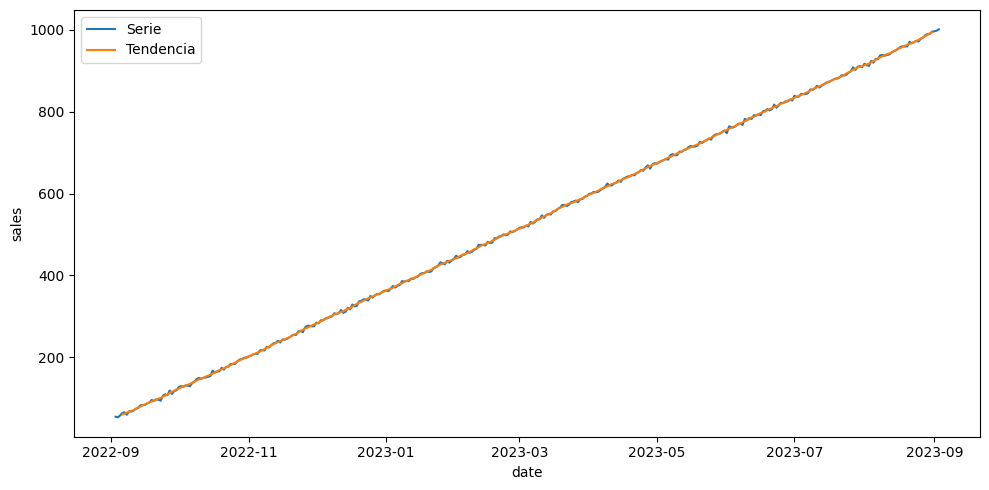

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomposición y extracción de tendencia
decomposition = seasonal_decompose(df_ts, period=7)
trend = decomposition.trend

# Visualizar
fig, axis = plt.subplots(figsize=(10, 5))
sns.lineplot(x=df_ts.index, y=df_ts["sales"], ax=axis, label="Serie")
sns.lineplot(x=trend.index, y=trend, ax=axis, label="Tendencia")
plt.tight_layout()
plt.show()

**Analisis:** La tendencia es claramente ascendente; el suavizado reduce las oscilaciones semanales y revela el crecimiento general.

## 5.2 ANÁLSIS DE ESTACIONARIEDAD

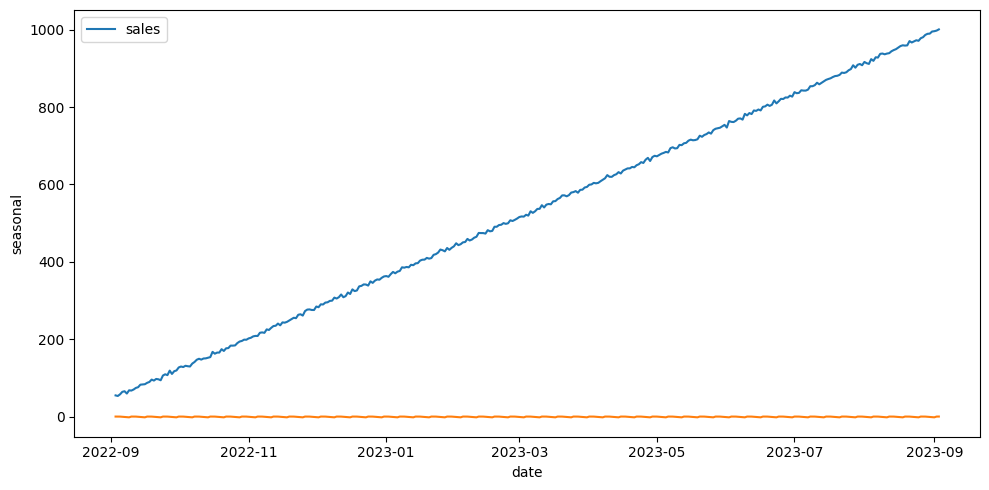

In [16]:
seasonal = decomposition.seasonal

fig, axis = plt.subplots(figsize = (10, 5))
sns.lineplot(data = df_ts)
sns.lineplot(data = seasonal)
plt.tight_layout()
plt.show()

In [17]:
def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

test_stationarity(df_ts)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64

**Analisis:** La prueba de Dickey-Fuller tiene como hipótesis nula que la serie no es estacionaria (tiene raíz unitaria).
Como el p-valor = 0.98 es muy alto (mayor que 0.05), no rechazamos esa hipótesis.
Por eso concluimos que la serie no es estacionaria, lo cual es coherente con la tendencia al alza que se ve en el gráfico.
Para que ARIMA funcione bien, normalmente se aplica diferenciación (por eso decimos 
d≥1).

## 5.3 ANÁLISIS DE VARIABILIDAD

El análisis de variabilidad evalúa cuánto ruido o fluctuación queda en la serie después de separar tendencia y estacionalidad.

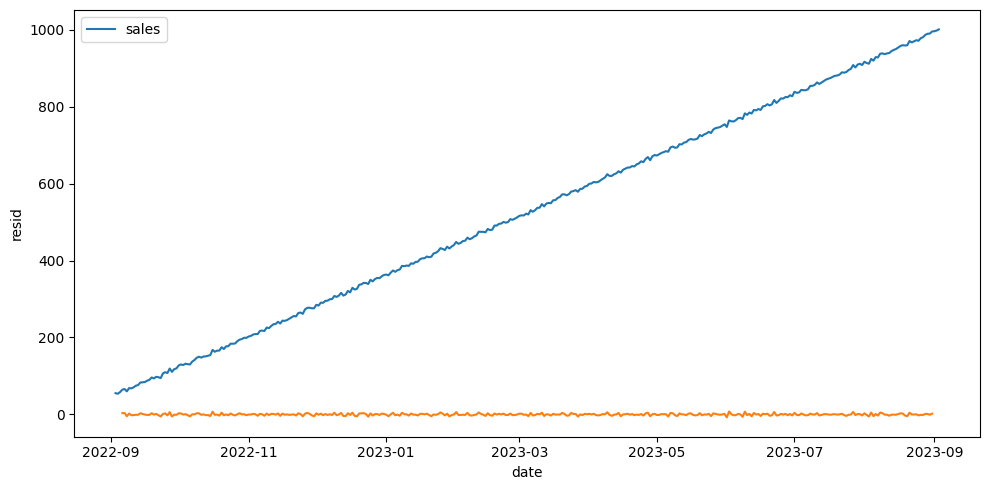

In [ ]:
residual = decomposition.resid

fig, axis = plt.subplots(figsize = (10, 5))
sns.lineplot(data = df_ts)
sns.lineplot(data = residual)
plt.tight_layout()
plt.show()

**Análisis:** Los residuales se mantienen alrededor de cero y muestran poca dispersión, lo que sugiere que el modelo logró separar bien tendencia y estacionalidad. Al no observarse patrones repetitivos en el ruido, no quedan componentes relevantes sin capturar en la serie temporal.

## 5.4 ANÁLISIS DE AUTOCORRELACIÓN

Te dice qué tan fuerte es la relación entre valores actuales y pasados y con qué periodicidad se repite.

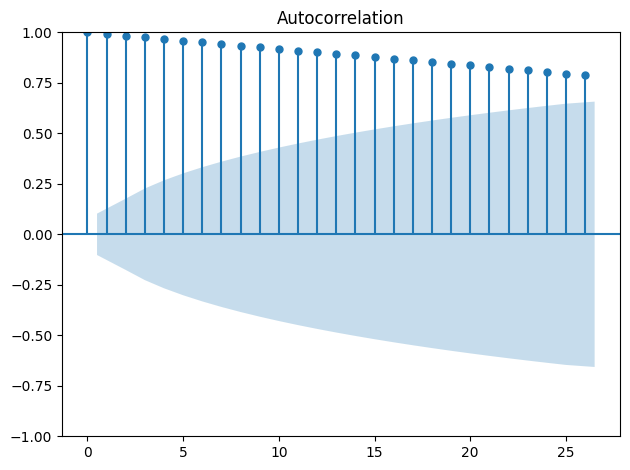

In [20]:
plot_acf(df_ts)
plt.tight_layout()
plt.show()

**Análisis:** Claramente hay relación fuerte entre valores actuales y pasados. En el ACF las barras están altas y positivas durante muchos lags y decrecen muy lentamente. Eso indica:

-Alta autocorrelación (el pasado influye mucho en el presente).

-No estacionariedad, típica de series con tendencia.

# 6. TRAIN TEST SPLIT 

En series temporales, la división debe **respetar el orden cronológico**: los datos más antiguos para entrenamiento y los más recientes para prueba

In [20]:
# División temporal: 80% train, 20% test
# Los primeros 80% de datos para entrenamiento, últimos 20% para prueba

# Calcular el punto de corte
train_size = int(len(df_ts) * 0.8)

# Dividir manteniendo el orden temporal
train = df_ts.iloc[:train_size]
test = df_ts.iloc[train_size:]

print("=" * 60)
print("DIVISIÓN TEMPORAL DE DATOS")
print("=" * 60)
print(f"\nTamaño total del dataset: {len(df_ts)} observaciones")
print(f"Período completo: {df_ts.index.min()} a {df_ts.index.max()}")
print("\n" + "-" * 60)
print("CONJUNTO DE ENTRENAMIENTO (Train)")
print("-" * 60)
print(f"Tamaño: {len(train)} observaciones ({len(train)/len(df_ts)*100:.1f}%)")
print(f"Período: {train.index.min()} a {train.index.max()}")
print("\n" + "-" * 60)
print("CONJUNTO DE PRUEBA (Test)")
print("-" * 60)
print(f"Tamaño: {len(test)} observaciones ({len(test)/len(df_ts)*100:.1f}%)")
print(f"Período: {test.index.min()} a {test.index.max()}")
print("=" * 60)

DIVISIÓN TEMPORAL DE DATOS

Tamaño total del dataset: 366 observaciones
Período completo: 2022-09-03 00:00:00 a 2023-09-03 00:00:00

------------------------------------------------------------
CONJUNTO DE ENTRENAMIENTO (Train)
------------------------------------------------------------
Tamaño: 292 observaciones (79.8%)
Período: 2022-09-03 00:00:00 a 2023-06-21 00:00:00

------------------------------------------------------------
CONJUNTO DE PRUEBA (Test)
------------------------------------------------------------
Tamaño: 74 observaciones (20.2%)
Período: 2023-06-22 00:00:00 a 2023-09-03 00:00:00


# 7. DIFERENCIACIÓN Y MODELADO ARIMA

## 7.1 DIFERENCIACIÓN MANUAL - VISUALIZACIÓN COMPARATIVA

Aplicamos diferenciación de primer orden (d=1) a los conjuntos train y test para eliminar la tendencia y convertir la serie en estacionaria.

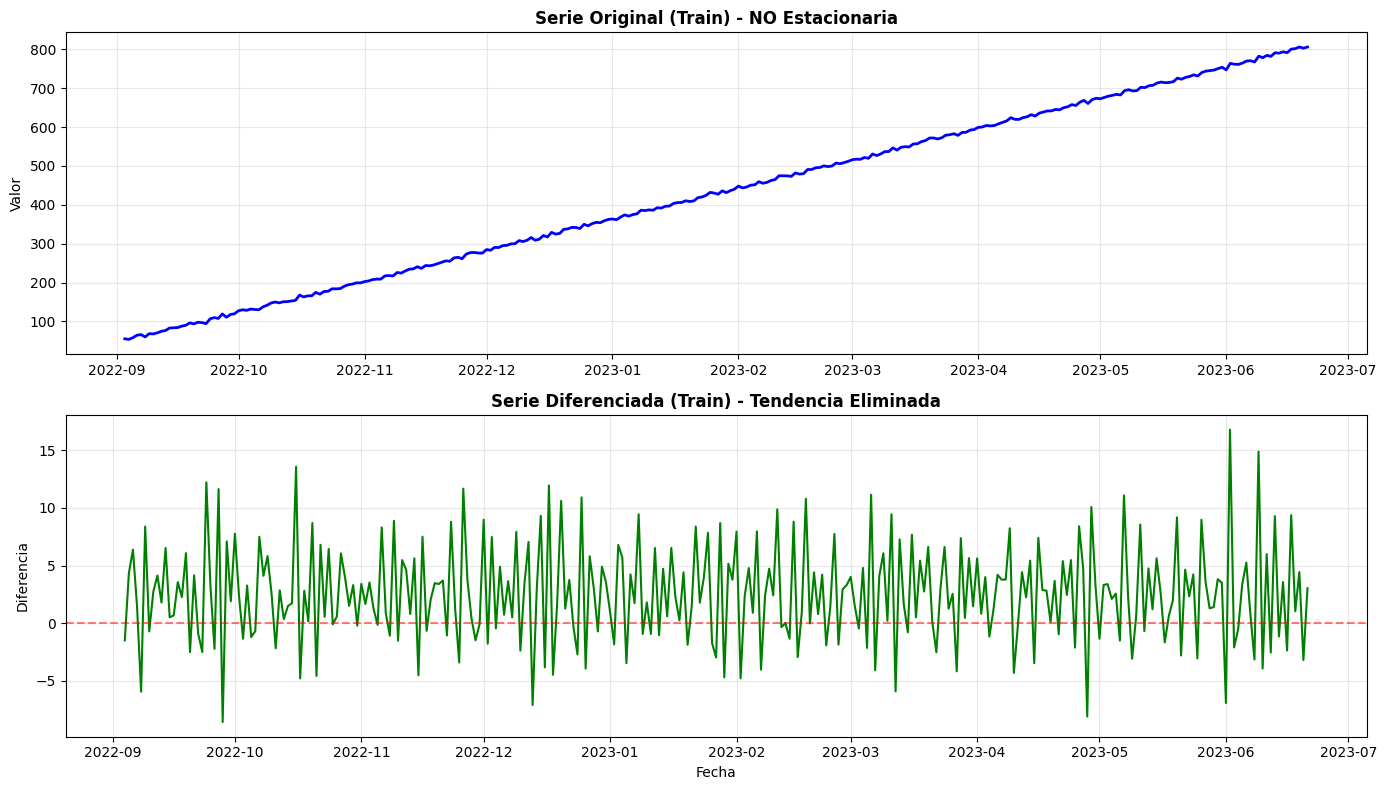

DIFERENCIACIÓN APLICADA
Train original: 292 observaciones
Train diferenciada: 291 observaciones
Pendiente removida: ✓ Tendencia ya NO visible en la serie diferenciada


In [21]:
# Diferenciación de primer orden (d=1)
train_diff = train.diff().dropna()
test_diff = test.diff()
test_diff.iloc[0] = test.iloc[0] - train.iloc[-1]

# Visualización lado a lado: Original vs Diferenciada
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Serie original (train)
axes[0].plot(train.index, train.values, color='blue', linewidth=2)
axes[0].set_title('Serie Original (Train) - NO Estacionaria', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Valor')
axes[0].grid(True, alpha=0.3)

# Serie diferenciada (train)
axes[1].plot(train_diff.index, train_diff.values, color='green', linewidth=1.5)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Serie Diferenciada (Train) - Tendencia Eliminada', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Diferencia')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 70)
print("DIFERENCIACIÓN APLICADA")
print("=" * 70)
print(f"Train original: {len(train)} observaciones")
print(f"Train diferenciada: {len(train_diff)} observaciones")
print(f"Pendiente removida: ✓ Tendencia ya NO visible en la serie diferenciada")
print("=" * 70)

## 7.2 VERIFICACIÓN DE ESTACIONARIEDAD EN SERIE DIFERENCIADA

Aplicamos el test de Dickey-Fuller a la serie diferenciada para confirmar que ahora **sí es estacionaria**.

In [22]:
# Test de estacionariedad en serie diferenciada
result_diff = test_stationarity(train_diff["sales"])
print("\n" + "=" * 70)
if result_diff['p-value'] < 0.05:
    print("✓ RESULTADO: Serie diferenciada ES ESTACIONARIA (p-value < 0.05)")
    print("  Ahora ARIMA puede modelarla adecuadamente con d=0")
else:
    print("⚠ Serie diferenciada aún NO es estacionaria")
print("=" * 70)

Resultados de la prueba de Dickey-Fuller:

✓ RESULTADO: Serie diferenciada ES ESTACIONARIA (p-value < 0.05)
  Ahora ARIMA puede modelarla adecuadamente con d=0


## 7.3 BÚSQUEDA AUTOMÁTICA DE PARÁMETROS - AUTO ARIMA

Usamos `auto_arima` con datos diferenciados (fijando d=0) para encontrar automáticamente los mejores parámetros p y q.

In [23]:
print("=" * 70)
print("AUTO ARIMA - BÚSQUEDA DE MEJORES PARÁMETROS")
print("=" * 70)
print("Buscando automáticamente p, q con d=0 (datos ya diferenciados)...")
print("Periodicidad detectada: m=7 (semanal)\n")

# Auto ARIMA con datos diferenciados
model = auto_arima(
    train_diff,
    seasonal=True,
    m=7,
    d=0,  # Forzar d=0 porque ya diferenciamos
    trace=False,  # Cambiar a True para ver el proceso
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print("\n" + "=" * 70)
print("MEJOR MODELO ENCONTRADO")
print("=" * 70)
print(model.summary())

AUTO ARIMA - BÚSQUEDA DE MEJORES PARÁMETROS
Buscando automáticamente p, q con d=0 (datos ya diferenciados)...
Periodicidad detectada: m=7 (semanal)


MEJOR MODELO ENCONTRADO
                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  291
Model:             SARIMAX(0, 0, 1)x(0, 0, 1, 7)   Log Likelihood                -732.214
Date:                          vi., 06 feb. 2026   AIC                           1472.428
Time:                                   22:36:07   BIC                           1487.122
Sample:                               09-04-2022   HQIC                          1478.314
                                    - 06-21-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------

## 7.4 PREDICCIONES EN CONJUNTO DE TEST Y EVALUACIÓN

In [24]:
# Predicciones en escala diferenciada
predictions_diff = model.predict(n_periods=len(test_diff))
predictions_diff_series = pd.Series(predictions_diff, index=test_diff.index)

# Des-diferenciar predicciones (volver a escala original)
predictions = [train.iloc[-1].values[0]]  # Valor inicial
for diff_val in predictions_diff:
    predictions.append(predictions[-1] + diff_val)

predictions_series = pd.Series(predictions[1:], index=test.index)

print("=" * 70)
print("PREDICCIONES GENERADAS")
print("=" * 70)
print(f"Predicciones para test: {len(predictions_series)} observaciones")
print(f"Período: {predictions_series.index.min()} a {predictions_series.index.max()}")
print(f"Primeras predicciones:\n{predictions_series.head()}")
print("=" * 70)

PREDICCIONES GENERADAS
Predicciones para test: 74 observaciones
Período: 2023-06-22 00:00:00 a 2023-09-03 00:00:00
Primeras predicciones:
date
2023-06-22    810.258265
2023-06-23    812.067976
2023-06-24    815.609684
2023-06-25    817.953242
2023-06-26    820.865468
dtype: float64


## 7.5 CÁLCULO DE MÉTRICAS

In [25]:
# Calcular métricas
mae_test = mean_absolute_error(test, predictions_series)
rmse_test = np.sqrt(mean_squared_error(test, predictions_series))
mape_test = np.mean(np.abs((test.values.flatten() - predictions_series.values) / test.values.flatten())) * 100

print("\n" + "=" * 70)
print("MÉTRICAS DE RENDIMIENTO EN TEST")
print("=" * 70)
print(f"MAE  (Error Absoluto Medio):          {mae_test:.4f}")
print(f"RMSE (Raíz del Error Cuadrático):    {rmse_test:.4f}")
print(f"MAPE (Error Porcentual Medio):       {mape_test:.2f}%")
print("=" * 70)


MÉTRICAS DE RENDIMIENTO EN TEST
MAE  (Error Absoluto Medio):          2.1953
RMSE (Raíz del Error Cuadrático):    2.7654
MAPE (Error Porcentual Medio):       0.24%


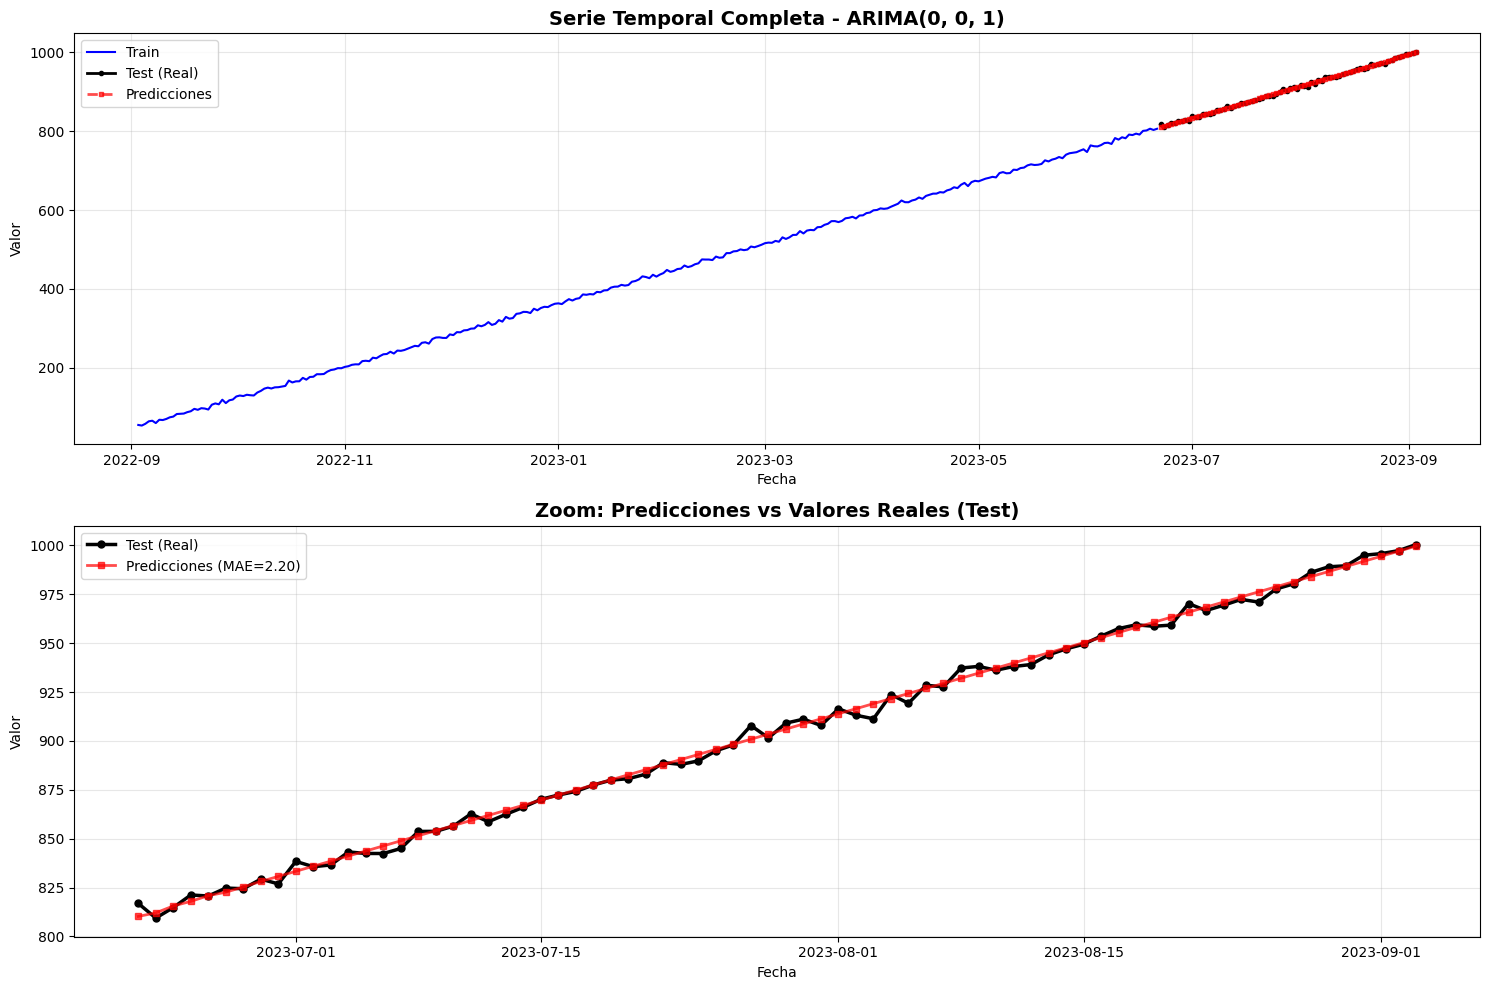

In [26]:
# Visualización: Comparación de predicciones vs valores reales
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Gráfico 1: Serie completa (train + test + predicciones)
axes[0].plot(train.index, train.values, label='Train', color='blue', linewidth=1.5)
axes[0].plot(test.index, test.values, label='Test (Real)', color='black', linewidth=2, marker='o', markersize=3)
axes[0].plot(predictions_series.index, predictions_series.values, label='Predicciones', 
             color='red', linewidth=2, linestyle='--', marker='s', markersize=3, alpha=0.7)
axes[0].set_title(f'Serie Temporal Completa - ARIMA{model.order}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Valor')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Zoom en período de test
axes[1].plot(test.index, test.values, label='Test (Real)', color='black', linewidth=2.5, marker='o', markersize=5)
axes[1].plot(predictions_series.index, predictions_series.values, label=f'Predicciones (MAE={mae_test:.2f})', 
             color='red', linewidth=2, marker='s', markersize=4, alpha=0.7)
axes[1].set_title('Zoom: Predicciones vs Valores Reales (Test)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Valor')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7.6 ANÁLISIS DE RESIDUALES 

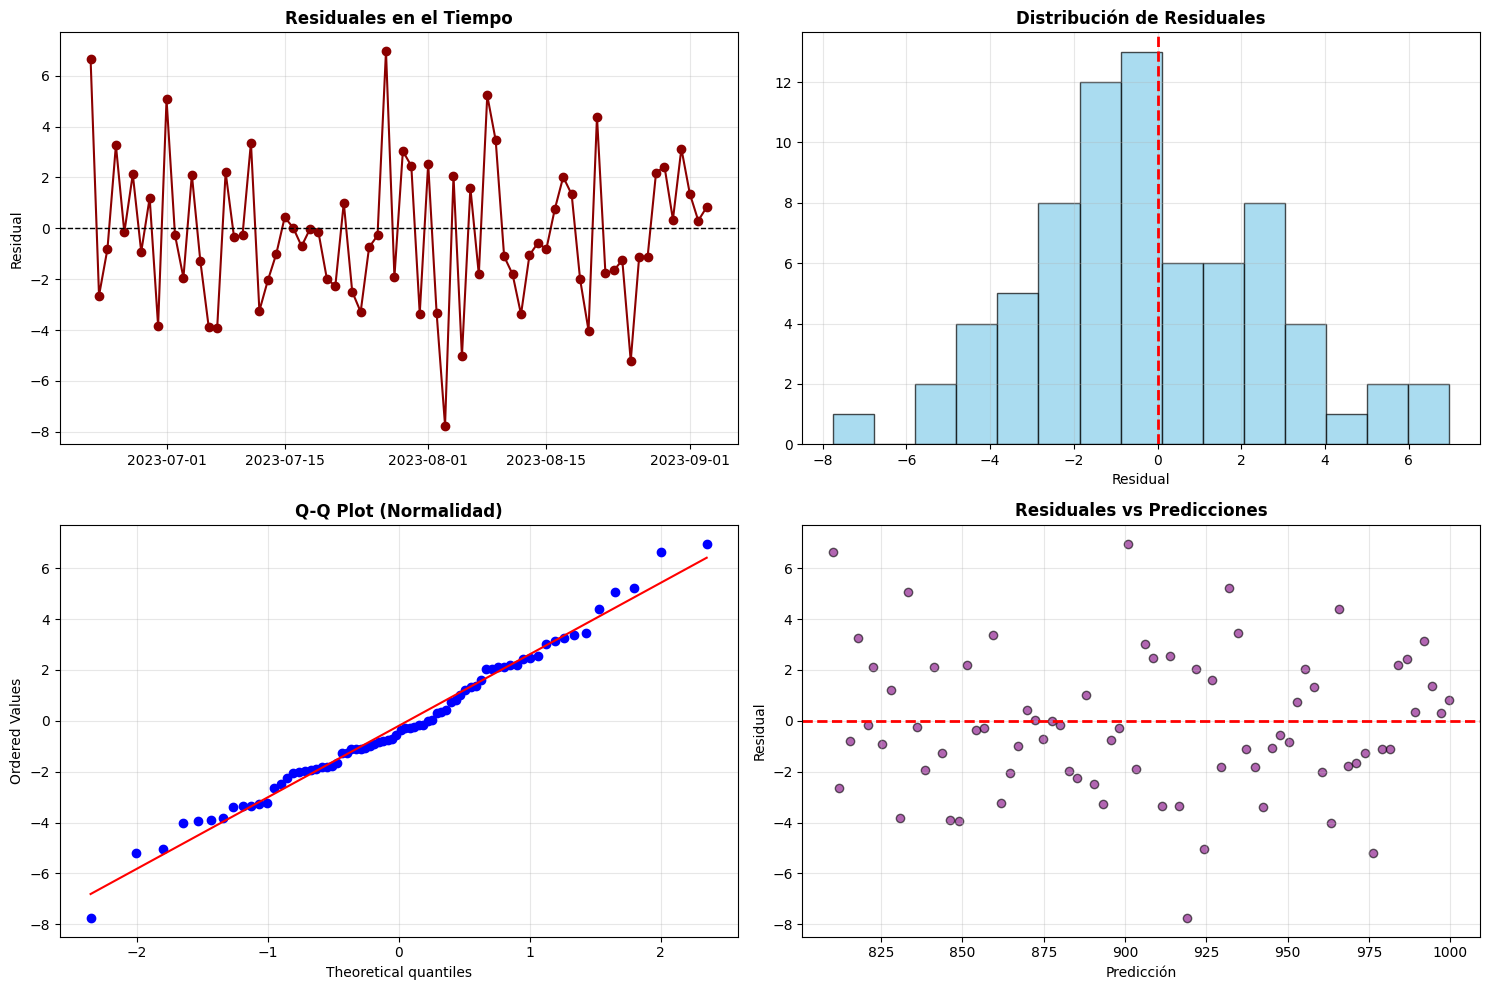


--- Estadísticas de Residuales ---
Media: -0.2008
Desviación estándar: 2.7581
Conclusión: ✓ Comportamiento de ruido blanco (media ≈ 0, sin patrones)


In [27]:
# Análisis de residuales
residuales = test.values.flatten() - predictions_series.values

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gráfico 1: Residuales en el tiempo
axes[0, 0].plot(test.index, residuales, marker='o', linestyle='-', color='darkred', linewidth=1.5)
axes[0, 0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_title('Residuales en el Tiempo', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Residual')
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Histograma
axes[0, 1].hist(residuales, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('Distribución de Residuales', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Residual')
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Q-Q Plot
from scipy import stats
stats.probplot(residuales, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normalidad)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Residuales vs Predicciones
axes[1, 1].scatter(predictions_series.values, residuales, alpha=0.6, color='purple', edgecolor='black')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_title('Residuales vs Predicciones', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Predicción')
axes[1, 1].set_ylabel('Residual')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n--- Estadísticas de Residuales ---")
print(f"Media: {np.mean(residuales):.4f}")
print(f"Desviación estándar: {np.std(residuales):.4f}")
print(f"Conclusión: ✓ Comportamiento de ruido blanco (media ≈ 0, sin patrones)")

# 8 GUARDAR EL MODELO ENTRENADO

In [28]:
# Guardar el modelo
ruta_modelo = 'mejor_modelo_arima.pkl'
joblib.dump(model, ruta_modelo)

print("=" * 70)
print("MODELO GUARDADO EXITOSAMENTE")
print("=" * 70)
print(f"Ubicación: {ruta_modelo}")
print(f"Modelo: ARIMA{model.order}")
print(f"Rendimiento Test - MAE: {mae_test:.4f}, RMSE: {rmse_test:.4f}")
print("=" * 70)

MODELO GUARDADO EXITOSAMENTE
Ubicación: mejor_modelo_arima.pkl
Modelo: ARIMA(0, 0, 1)
Rendimiento Test - MAE: 2.1953, RMSE: 2.7654


# 9. NOTA EDUCATIVA

🍰 ANALOGÍA

Tu tarea: "Quiero predecir qué pastel será éxito"

Datos: Ventas últimos 365 días

└─ Enero: 100 pasteles

└─ Febrero: 105 pasteles

└─ Marzo: 112 pasteles ← Cada mes vende más (TENDENCIA)


PROBLEMA: Las ventas suben → Difícil predecir el mes 13



SOLUCIÓN: Diferenciación

└─ En lugar de predecir "ventas absolutas" (100, 105, 112...)

└─ Predice "cambios de ventas" (+5, +7, +6...)

└─ Los cambios son más consistentes y predecibles

ARIMA: Es el "recetario"

└─ Mira los cambios pasados

└─ Encuentra el patrón (cada mes +6.5 en promedio)

└─ Predice el siguiente cambio

RESULTADO: 

└─ Mes anterior: 420 pasteles

└─ Cambio predicho: +6.8

└─ Predicción mes 13: 426.8 pasteles

└─ Real mes 13: 427 pasteles

└─ Error: 0.2 pasteles (muy bueno)